c:\Users\USER\.conda\envs\vlm\Lib\site-packages\pyvista\jupyter\notebook.py:56: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


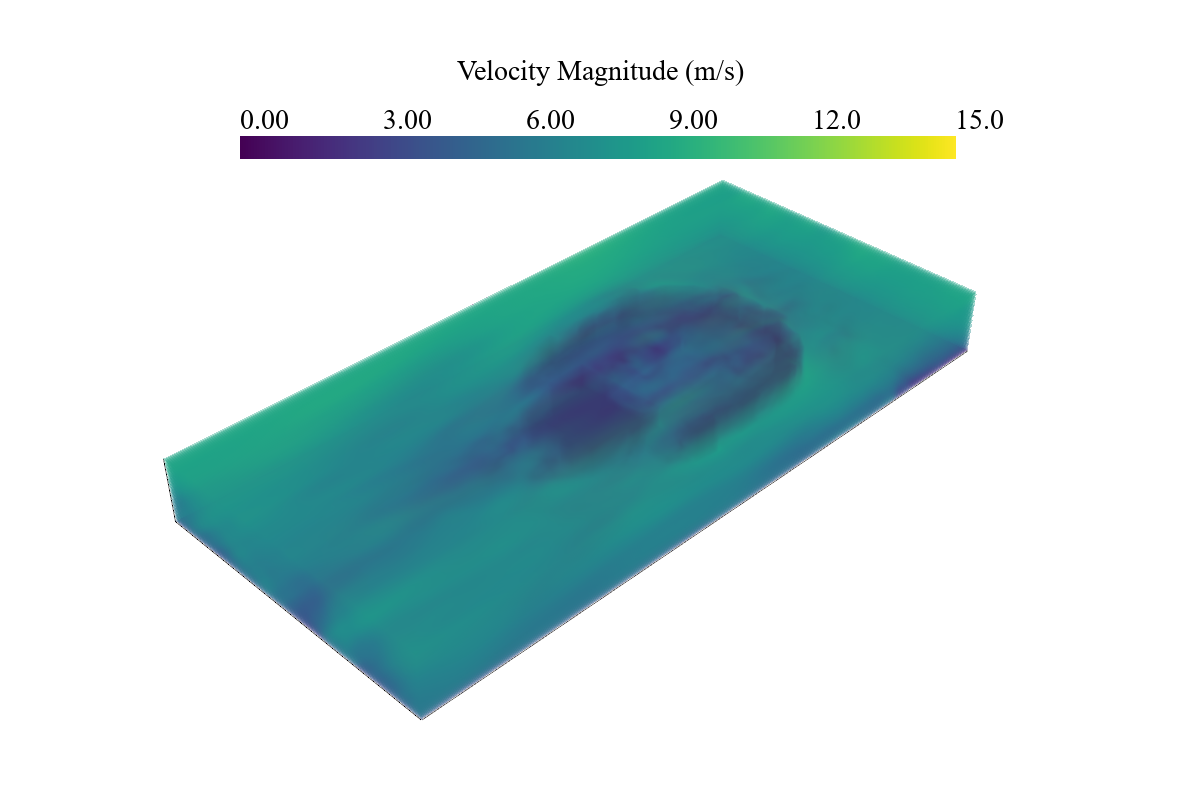

In [1]:
import pyvista as pv
import numpy as np

# Read the data
mesh = pv.read(r"bp_50percent_75.vtk")
bounds = mesh.bounds
z_min, z_max = bounds[4], bounds[5]

# Create plotter with static background
plotter = pv.Plotter(lighting='none')

# Create slices
z_positions = np.linspace(z_min, z_max, 50)
for z_pos in z_positions:
    slice_z = mesh.slice(normal='z', origin=(0, 0, z_pos))
    if slice_z.n_points > 0:
        plotter.add_mesh(slice_z, 
                        opacity=0.4,
                        cmap='viridis',
                        clim=[0, 15],
                        scalars='U',
                        label=None,
                        lighting=False,
                        show_edges=False,
                        show_scalar_bar=False,
                        interpolate_before_map=False)

bar = plotter.add_scalar_bar(
    title='Velocity Magnitude (m/s)\n',
    n_labels=6,
    title_font_size=28,
    label_font_size=28,
    position_x=0.2,
    position_y=0.80,
    font_family='times',
)

plotter.show_bounds(
   show_xaxis=True,
   xtitle=" ",
   show_yaxis=True,
   ytitle=" ",
   show_zaxis=True,
   ztitle=" ",
   show_xlabels=False,
   show_ylabels=False,
   show_zlabels=False,
   location='outer',
   font_family='times',
)

bar.GetTitleTextProperty().SetLineSpacing(1.01)

# render scalar-bar text in the actual Times New Roman TTF (VTK_FONT_FILE = 4)
for _tp in (bar.GetTitleTextProperty(), bar.GetLabelTextProperty()):
    _tp.SetFontFamily(4)
    _tp.SetFontFile(r'C:\Windows\Fonts\times.ttf')

plotter.window_size = [1200, 800]
plotter.camera.zoom(1.1)
plotter.show()